The following notebook contains broad data cleaning and analysis of the [https://www.kaggle.com/competitions/home-credit-default-risk/overview](https://www.kaggle.com/competitions/home-credit-default-risk/overview) dataset.

# Dataset structure

The dataset is made of 10 tables, 346 columns, and a total of 2.68GB of data. Due to simple volume of information, data cleaning is going to be partitioned on table by table basis.


The tables have following structure and [description](https://www.kaggle.com/competitions/home-credit-default-risk/data):
![images\dataset_structure.png](images\dataset_structure.png)




### Table descriptions:

- **application_{train|test}.csv**  
    - This is the main table, broken into two files for Train (with TARGET) and Test (without TARGET).  
    - Static data for all applications. One row represents one loan in our data sample.

- **bureau.csv**  
    - All client's previous credits provided by other financial institutions that were reported to Credit Bureau (for clients who have a loan in our sample).  
    - For every loan in our sample, there are as many rows as number of credits the client had in Credit Bureau before the application date.

- **bureau_balance.csv**  
    - Monthly balances of previous credits in Credit Bureau.  
    - This table has one row for each month of history of every previous credit reported to Credit Bureau – i.e the table has (#loans in sample * # of relative previous credits * # of months where we have some history observable for the previous credits) rows.

- **POS_CASH_balance.csv**  
    - Monthly balance snapshots of previous POS (point of sales) and cash loans that the applicant had with Home Credit.  
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credits * # of months in which we have some history observable for the previous credits) rows.

- **credit_card_balance.csv**  
    - Monthly balance snapshots of previous credit cards that the applicant has with Home Credit.  
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credit cards * # of months where we have some history observable for the previous credit card) rows.

- **previous_application.csv**  
    - All previous applications for Home Credit loans of clients who have loans in our sample.  
    - There is one row for each previous application related to loans in our data sample.

- **installments_payments.csv**  
    - Repayment history for the previously disbursed credits in Home Credit related to the loans in our sample.  
    - There is a) one row for every payment that was made plus b) one row each for missed payment.  
    - One row is equivalent to one payment of one installment OR one installment corresponding to one payment of one previous Home Credit credit related to loans in our sample.

- **HomeCredit_columns_description.csv**  
    - This file contains descriptions for the columns in the various data files.

#### Considerations
One obvious goal emerges - given the train/test dataset, we would want to build a predictive model that would determine someone defaulting on a loan. Given tables with more than one entry per person, we will likely want to build intermediary models that will predict other valuable information and act as features for our final model.

# Imports

In [1]:
import os
import pandas as pd

from helpers.utils import plotting_helper
plotting_helper.set_plot_style()

# Table Analysis

We first load all the tables and check their data inforamtion:

Note:
In the table data\raw_csv\HomeCredit_columns_description.csv, the table was modified to avoud utf read error.
200,previous_application.csv,NAME_PORTFOLIO,"Was the previous application for CASH, POS, CAR, �",

In [2]:

data_dir = "data/raw_csv"
csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

tables = {}
for file in csv_files:
    table_name = file.replace('.csv', '')
    tables[table_name] = pd.read_csv(os.path.join(data_dir, file))
    print("loaded", table_name, "with shape", tables[table_name].shape)

loaded application_test with shape (48744, 121)
loaded application_train with shape (307511, 122)
loaded bureau with shape (1716428, 17)
loaded bureau_balance with shape (27299925, 3)
loaded credit_card_balance with shape (3840312, 23)
loaded HomeCredit_columns_description with shape (219, 5)
loaded installments_payments with shape (13605401, 8)
loaded POS_CASH_balance with shape (10001358, 8)
loaded previous_application with shape (1670214, 37)
loaded sample_submission with shape (48744, 2)


We can see that the application test and application shape tables are much wider than others - other tables provide supplementary information that could be used for further analysis.

# HomeCredit_columns_description
We start our analysis with a descriptor table, which provides context and understanding into other columns. Without this context, a manual analysis of values or EDA makes very little sense.

In [3]:
descriptions = tables['HomeCredit_columns_description']
if 'Unnamed: 0' in descriptions.columns:
    print("Dropping 'Unnamed: 0' column from descriptions")
    descriptions.drop(columns=['Unnamed: 0'], inplace=True)

descriptions

Dropping 'Unnamed: 0' column from descriptions


,Table,Row,Description,Special
0,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
...,...,...,...,...
214,installments_payments.csv,NUM_INSTALMENT_NUMBER,On which installment we observe payment,NaN
215,installments_payments.csv,DAYS_INSTALMENT,When the installment of previous credit was su...,time only relative to the application
216,installments_payments.csv,DAYS_ENTRY_PAYMENT,When was the installments of previous credit p...,time only relative to the application
217,installments_payments.csv,AMT_INSTALMENT,What was the prescribed installment amount of ...,NaN


In [4]:
descriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Table        219 non-null    object
 1   Row          219 non-null    object
 2   Description  219 non-null    object
 3   Special      86 non-null     object
dtypes: object(4)
memory usage: 7.0+ KB


The descriptions table consists of 219 unique entries. Nan Values are only found besides special comments, lack of which is possible.

#### ColumnDescriber

We then implement a custom class, which will highly simplify investigating various columns for data cleaning.
It provides information on columns:
* Source table
* Description
* Presence of special information
* Number of nan values
* Number of unique values
* Data type
* And a few sample values


In [5]:
from helpers import table_navigator
import importlib
importlib.reload(table_navigator)
pd.set_option('display.max_colwidth', 2)
describer = table_navigator.ColumnDescriber(tables)
describer.describe("SK_ID_CURR")


,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
0,application_train,SK_ID_CURR,ID of loan in our sample,NaN,0,307511,int64,"[100002, 100003, 100004]"
122,bureau,SK_ID_CURR,"ID of loan in our sample - one loan in our sample can have 0,1,2 or more related previous credits in credit bureau",hashed,0,305811,int64,"[215354, 162297, 402440]"
143,POS_CASH_balance,SK_ID_CURR,ID of loan in our sample,NaN,0,337252,int64,"[182943, 367990, 397406]"
151,credit_card_balance,SK_ID_CURR,ID of loan in our sample,hashed,0,103558,int64,"[378907, 363914, 371185]"
174,previous_application,SK_ID_CURR,ID of loan in our sample,hashed,0,338857,int64,"[271877, 108129, 122040]"
212,installments_payments,SK_ID_CURR,ID of loan in our sample,hashed,0,339587,int64,"[161674, 151639, 193053]"


From the get got, we see that although customer ID is shared between all tables, not each instance of application has that kind of information.

# Application Table
We first look into the data stored in application table:

In [6]:
application =tables['application_train']
describer = table_navigator.ColumnDescriber(tables, 'application_train')
display(application.shape)
expected_values = application.shape[0]

(307511, 122)

The table contains a significant ammount of columns which will need to be investigated separately. The information on column contents will be taken from HomeCredit_columns_description file.

The number of rows is too large to be investigated as a whole, consequently, they will e divided into meaningful groups and investiated thus.

## Column group analysis

In [7]:
application_columns = {}
cat_columns =[]
numeric_columns = []
bool_columns = []


### core identifiers

In [8]:
core_identification = [
    'SK_ID_CURR',
    'TARGET'
]

application_columns['core_identification'] = core_identification
bool_columns.extend('TARGET')

describer.describe(core_identification)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
0,application_train,SK_ID_CURR,ID of loan in our sample,NaN,0,307511,int64,"[100002, 100003, 100004]"
1,application_train,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN,0,2,int64,"[1, 0]"


* Core identification columns are shared between tables. 
* Each ID value is unique.

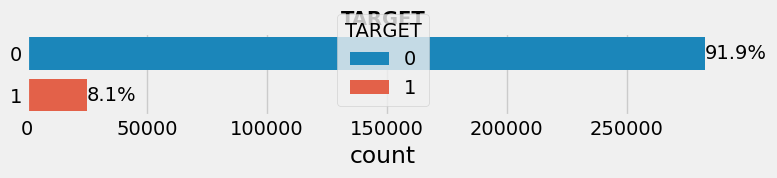

In [9]:
from helpers.utils import cleaner_helper
cleaner_helper.plot_categorical_distribution(
    application,'TARGET',"TARGET");

We see that our target variable is highly imbalanced. Consequently, **Accuracy becomes near meningless**. Weighted metrics, such as **f1_macro, Precision-Recall curve** will need to be used when training the model.

#### basic loan information

In [10]:
loan_basics = [
    'NAME_CONTRACT_TYPE',  # Cash or revolving loan
    'AMT_CREDIT',          # Credit amount
    'AMT_ANNUITY',         # Loan annuity
    'AMT_GOODS_PRICE'      # Price of goods for consumer loans
]
application_columns['loan_basics'] = loan_basics


describer.describe(loan_basics)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
2,application_train,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN,0,2,object,"[Cash loans, Revolving loans]"
8,application_train,AMT_CREDIT,Credit amount of the loan,NaN,0,5603,float64,"[406597.5, 1293502.5, 135000.0]"
9,application_train,AMT_ANNUITY,Loan annuity,NaN,12,13672,float64,"[24700.5, 35698.5, 6750.0]"
10,application_train,AMT_GOODS_PRICE,For consumer loans it is the price of the goods for which the loan is given,NaN,278,1002,float64,"[351000.0, 1129500.0, 135000.0]"


* all loans are either cash or revolving and are known amount.
* Few values are abset for loan annuity.
* Price of goods is oft missing for consumer loans.

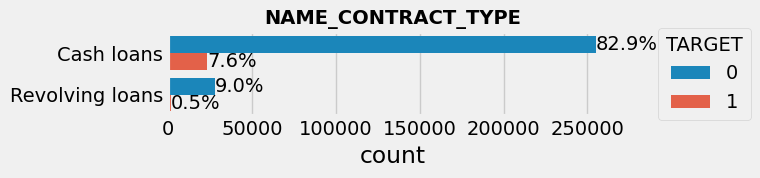

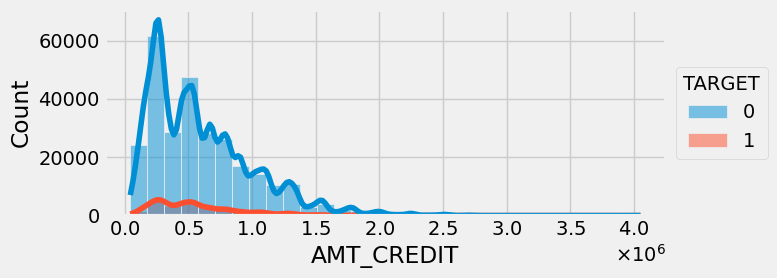

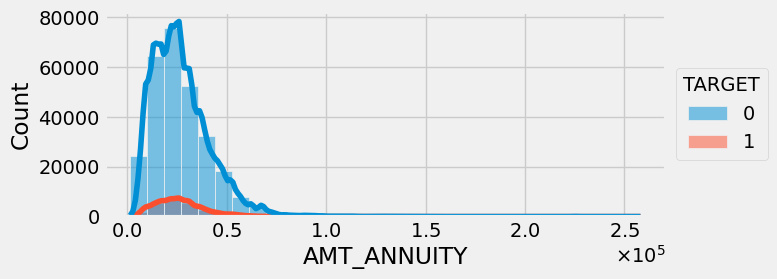

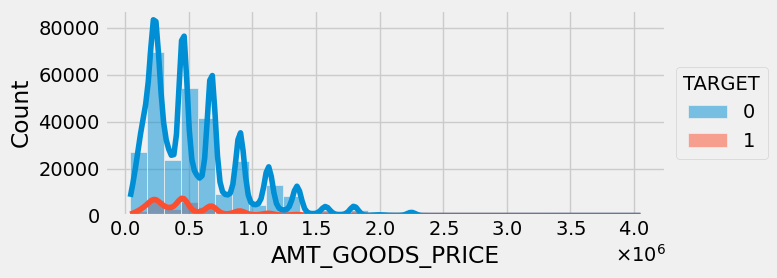

In [11]:
importlib.reload(cleaner_helper)
cleaner_helper.plot_categorical_distribution(
    application,'NAME_CONTRACT_TYPE', hue="TARGET");

for col in ['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']:
    cleaner_helper.plot_numeric_distribution(
        application,col, hue ="TARGET");


* Revolving loans are a minority.
* Credit goes up to 1 million.
* The distributions are right skewed and, incase of goods price, partially discrete.

In [12]:
application[loan_basics].describe()

,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
count,3.075110e+05,307499.000000,3.072330e+05
mean,5.990260e+05,27108.573909,5.383962e+05
std,4.024908e+05,14493.737315,3.694465e+05
min,4.500000e+04,1615.500000,4.050000e+04
25%,2.700000e+05,16524.000000,2.385000e+05
50%,5.135310e+05,24903.000000,4.500000e+05
75%,8.086500e+05,34596.000000,6.795000e+05
max,4.050000e+06,258025.500000,4.050000e+06


* Houses cost from hundreds of thousands to millions.
* People oft loan almost all gouse price.
* Extreme values are simply expensive houses.

#### Financial info

In [13]:
financial_info = [
    'AMT_INCOME_TOTAL',      # Client income
    'NAME_INCOME_TYPE',      # Income type (businessman, working, etc.)
    'OCCUPATION_TYPE'        # Client occupation
]

application_columns['financial_info'] = financial_info

describer.describe(financial_info)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
7,application_train,AMT_INCOME_TOTAL,Income of the client,NaN,0,2548,float64,"[202500.0, 270000.0, 67500.0]"
12,application_train,NAME_INCOME_TYPE,"Clients income type (businessman, working, maternity leave,�)",NaN,0,8,object,"[Working, State servant, Commercial associate]"
28,application_train,OCCUPATION_TYPE,What kind of occupation does the client have,NaN,96391,18,object,"[Laborers, Core staff, Accountants]"


* Income and income type of client is always known.
* Clients occupation type if often unknown.

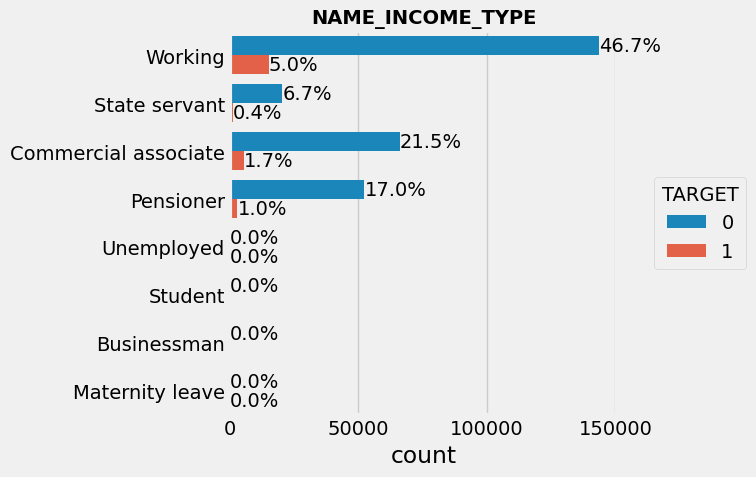

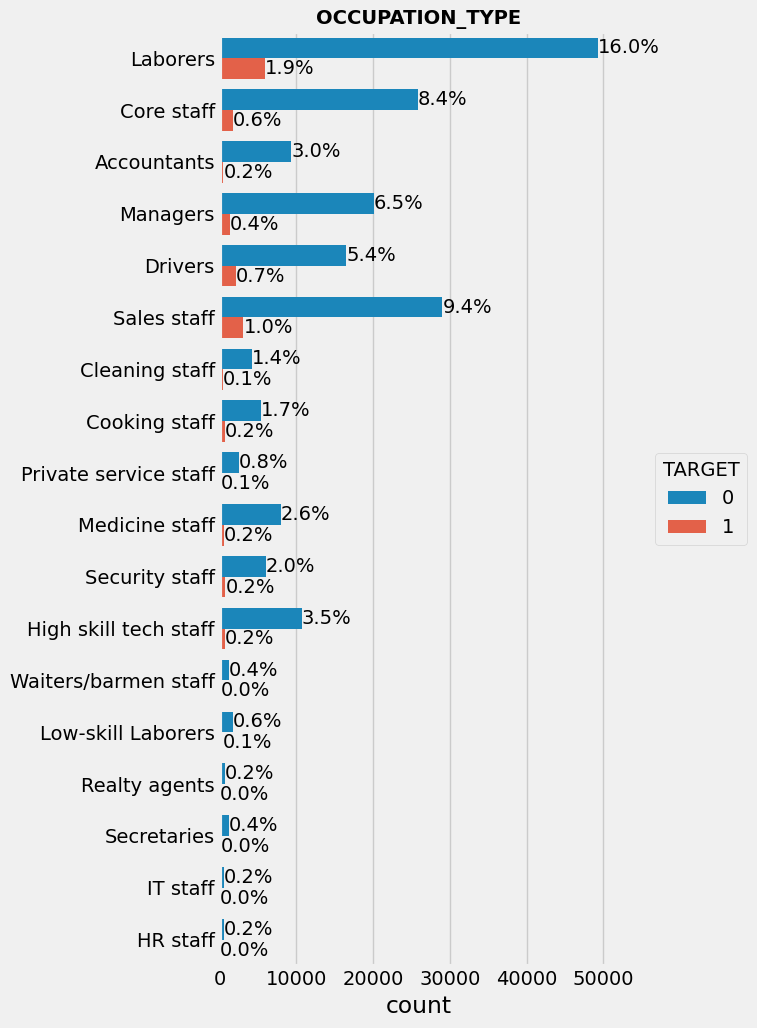

In [14]:
for col in ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE']:
    cleaner_helper.plot_categorical_distribution(
        application, col, hue="TARGET")

In [15]:
income_types_with_occupation = (
    application
    .loc[application["OCCUPATION_TYPE"].isna()]
    .groupby("NAME_INCOME_TYPE")
    .count()["AMT_INCOME_TOTAL"]
    .sort_values(ascending=False)
)
print(income_types_with_occupation)

NAME_INCOME_TYPE
Pensioner               55357
Working                 24920
Commercial associate    12297
State servant           3787 
Unemployed              22   
Student                 5    
Businessman             2    
Maternity leave         1    
Name: AMT_INCOME_TOTAL, dtype: int64


Majority of people whose profession is not known are pensioners, but other groups are included. Consequently, the missing values could be a myriad of various reasons. Most likely is clients not maching one of the neat categories and thus not being classified. **If this can be confirmed, they should be assigned as "other".**

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

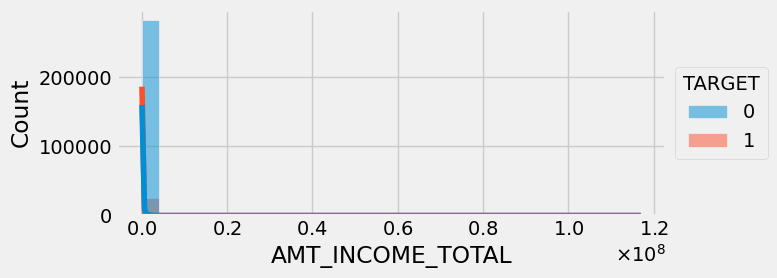

In [16]:
cleaner_helper.plot_numeric_distribution(
    application, 'AMT_INCOME_TOTAL', hue="TARGET",)
application['AMT_INCOME_TOTAL'].describe()

The distribution is significantly right skewed by extreme earners.
* **An outlier insensitive ML model should be used**
* **Otherwise the outlier needs to be treated**

WE thus investigate the distribution after removal of top 4% highest earners.

count    307511.000000
mean     163638.695826
std      75820.891913 
min      25650.000000 
25%      112500.000000
50%      147150.000000
75%      202500.000000
max      360000.000000
Name: AMT_INCOME_TOTAL, dtype: float64

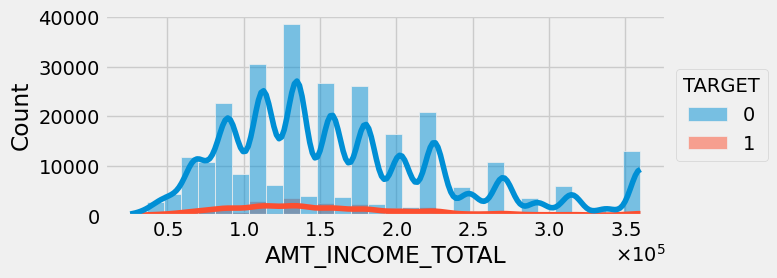

In [17]:

clipped_income = application['AMT_INCOME_TOTAL'].clip(upper=application['AMT_INCOME_TOTAL'].quantile(0.96))
cleaner_helper.plot_numeric_distribution(
    application.assign(AMT_INCOME_TOTAL=clipped_income), 'AMT_INCOME_TOTAL', hue="TARGET")
clipped_income.describe()

* Income distribution is significantly skewed to the tright.
* Income apears to be teared rather than fully continous.

#### Assets

In [18]:
assets = [
    'FLAG_OWN_CAR',          # Owns a car
    'FLAG_OWN_REALTY',       # Owns house/flat
    'OWN_CAR_AGE'            # Age of car
]

application_columns['assets'] = assets

describer.describe(assets)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
4,application_train,FLAG_OWN_CAR,Flag if the client owns a car,NaN,0,2,object,"[N, Y]"
5,application_train,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN,0,2,object,"[Y, N]"
21,application_train,OWN_CAR_AGE,Age of client's car,NaN,202929,62,float64,"[26.0, 17.0, 8.0]"


* Car and home ofnership is known for each client.
* Car age is missing (possibly because not everyone owns a car)?

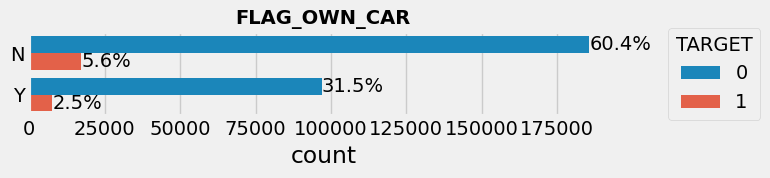

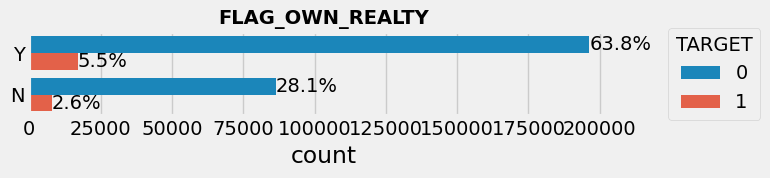

In [19]:
for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    cleaner_helper.plot_categorical_distribution(
        application, col, hue="TARGET")


In [20]:
application.loc[(application["FLAG_OWN_CAR"]=="Y") & application["OWN_CAR_AGE"].isna(), assets].shape

(5, 3)

* Only ages of 5 cars owned are unknown.
* There is no realistic way to impute them more thoroughly than mean.
* At the same time, **car ownership and car age encode identical information**. Thus, Feature reduction would be required for a tree model.

<Axes: xlabel='OWN_CAR_AGE', ylabel='Count'>

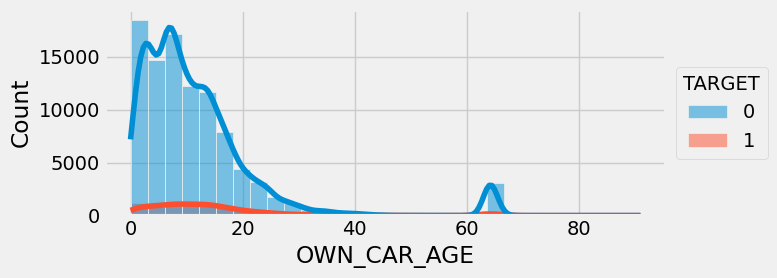

In [21]:
cleaner_helper.plot_numeric_distribution(
    application, 'OWN_CAR_AGE', hue="TARGET")

* Cars are bimodally distributed. Likely difference between "everyday" and "collectors" cars.


#### Time-based features

In [22]:
time_features = [
              # Age in days
    'DAYS_EMPLOYED',         # Days employed
    'DAYS_REGISTRATION',     # Days since registration change
    'DAYS_ID_PUBLISH',       # Days since ID document change
    'DAYS_LAST_PHONE_CHANGE', # Days since phone change
    'HOUR_APPR_PROCESS_START'
]

application_columns['time_features'] = time_features

describer.describe(time_features)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
18,application_train,DAYS_EMPLOYED,How many days before the application the person started current employment,time only relative to the application,0,12574,int64,"[-637, -1188, -225]"
19,application_train,DAYS_REGISTRATION,How many days before the application did client change his registration,time only relative to the application,0,15688,float64,"[-3648.0, -1186.0, -4260.0]"
20,application_train,DAYS_ID_PUBLISH,How many days before the application did client change the identity document with which he applied for the loan,time only relative to the application,0,6168,int64,"[-2120, -291, -2531]"
33,application_train,HOUR_APPR_PROCESS_START,Approximately at what hour did the client apply for the loan,rounded,0,24,int64,"[10, 11, 9]"
95,application_train,DAYS_LAST_PHONE_CHANGE,How many days before application did client change phone,NaN,1,3773,float64,"[-1134.0, -828.0, -815.0]"


* No nan values observed, except for a single individual who has not changed their phone for a long while.

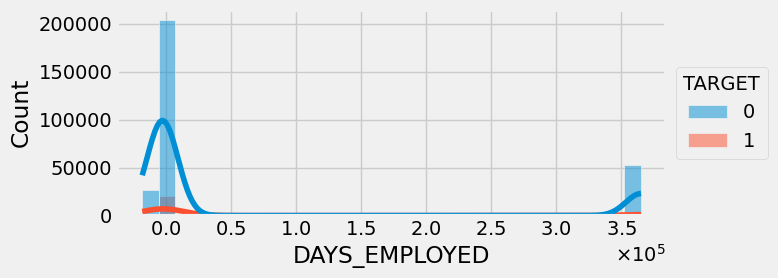

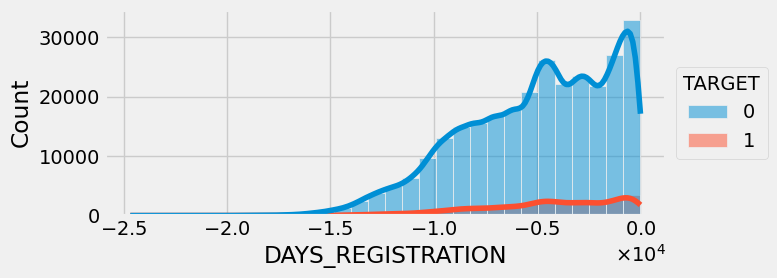

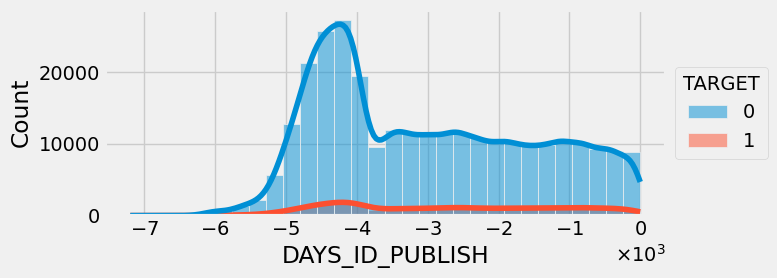

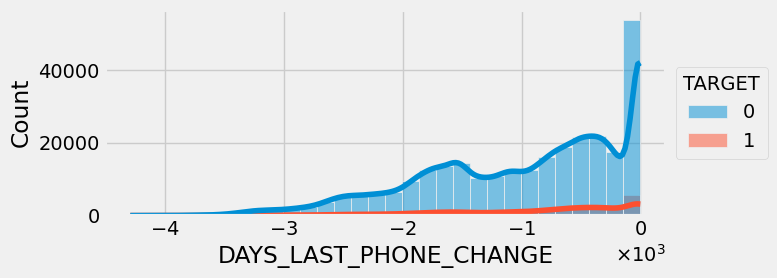

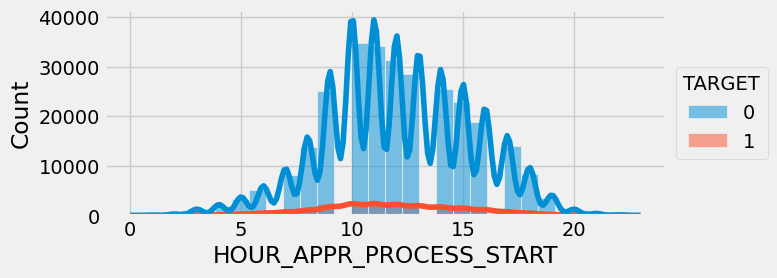

In [23]:
importlib.reload(cleaner_helper)
for col in time_features:
    cleaner_helper.plot_numeric_distribution(
        application, col, hue="TARGET")

#### Contact information flags

In [24]:
contact_flags = [
    'FLAG_MOBIL',            # Mobile phone provided
    'FLAG_EMP_PHONE',        # Work phone provided
    'FLAG_WORK_PHONE',       # Work phone provided (duplicate?)
    'FLAG_CONT_MOBILE',      # Mobile phone reachable
    'FLAG_PHONE',            # Home phone provided
    'FLAG_EMAIL'             # Email provided
]

application_columns['contact_flags'] = contact_flags

describer.describe(contact_flags)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
22,application_train,FLAG_MOBIL,"Did client provide mobile phone (1=YES, 0=NO)",NaN,0,2,int64,"[1, 0]"
23,application_train,FLAG_EMP_PHONE,"Did client provide work phone (1=YES, 0=NO)",NaN,0,2,int64,"[1, 0]"
24,application_train,FLAG_WORK_PHONE,"Did client provide home phone (1=YES, 0=NO)",NaN,0,2,int64,"[0, 1]"
25,application_train,FLAG_CONT_MOBILE,"Was mobile phone reachable (1=YES, 0=NO)",NaN,0,2,int64,"[1, 0]"
26,application_train,FLAG_PHONE,"Did client provide home phone (1=YES, 0=NO)",NaN,0,2,int64,"[1, 0]"
27,application_train,FLAG_EMAIL,"Did client provide email (1=YES, 0=NO)",NaN,0,2,int64,"[0, 1]"


* No missing values

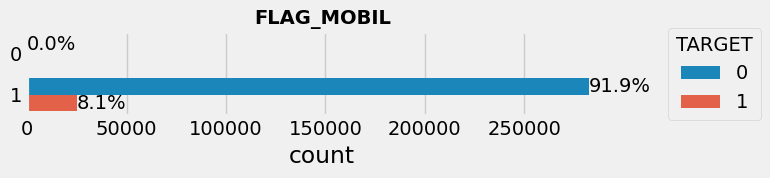

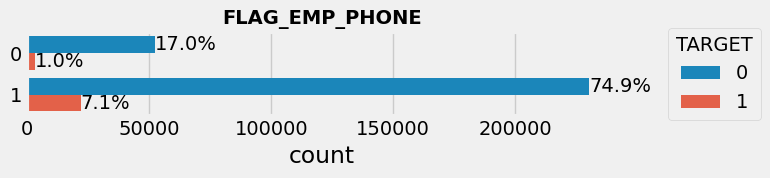

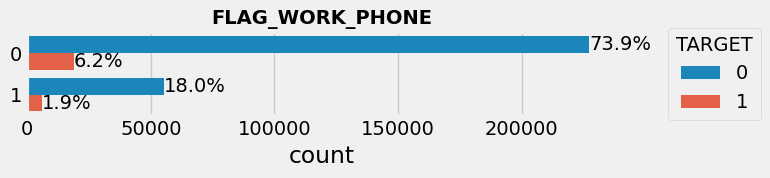

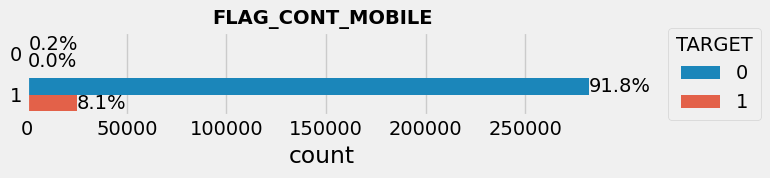

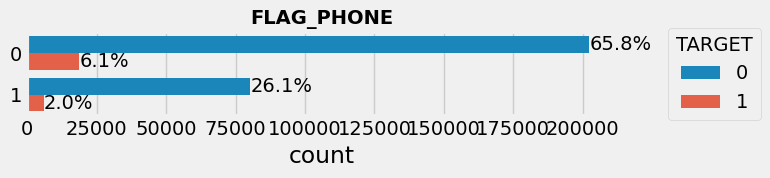

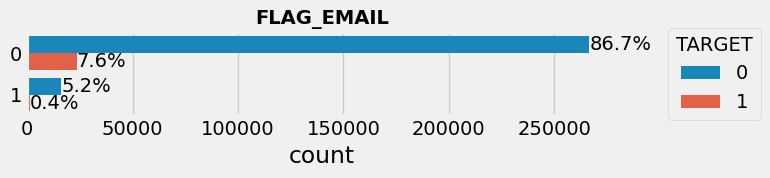

In [25]:
for col in contact_flags:
    cleaner_helper.plot_categorical_distribution(
        application, col, hue="TARGET")

* Majority of individuals provided extensive personal details.

#### Demographics

In [26]:
demographics = [
    'CODE_GENDER',           # Gender of client
    'NAME_EDUCATION_TYPE',   # Education level
    'NAME_FAMILY_STATUS',    # Family status
    'CNT_CHILDREN',          # Number of children
    'CNT_FAM_MEMBERS'        # Number of family members
    'DAYS_BIRTH',  
]

application_columns['demographics'] = demographics

describer.describe(demographics)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
3,application_train,CODE_GENDER,Gender of the client,NaN,0,3,object,"[M, F, XNA]"
6,application_train,CNT_CHILDREN,Number of children the client has,NaN,0,15,int64,"[0, 1, 2]"
13,application_train,NAME_EDUCATION_TYPE,Level of highest education the client achieved,NaN,0,5,object,"[Secondary / secondary special, Higher education, Incomplete higher]"
14,application_train,NAME_FAMILY_STATUS,Family status of the client,NaN,0,6,object,"[Single / not married, Married, Civil marriage]"


* Full information known
* Status of a few familly members is missing.

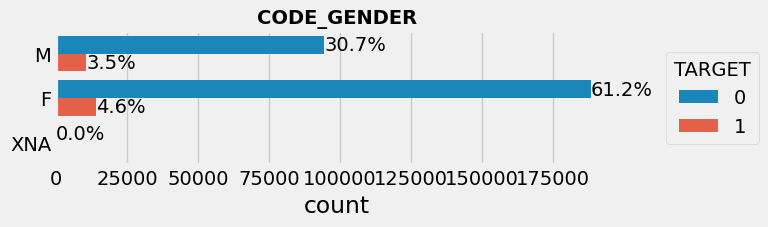

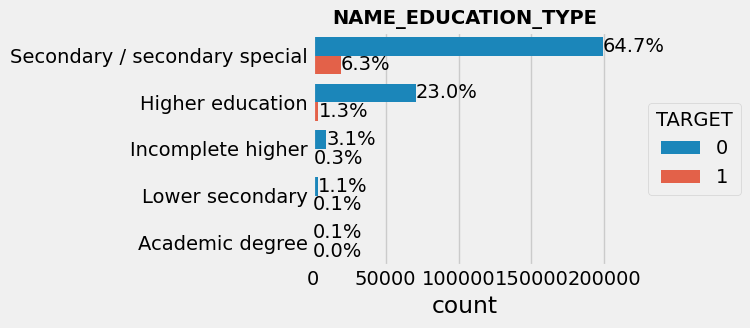

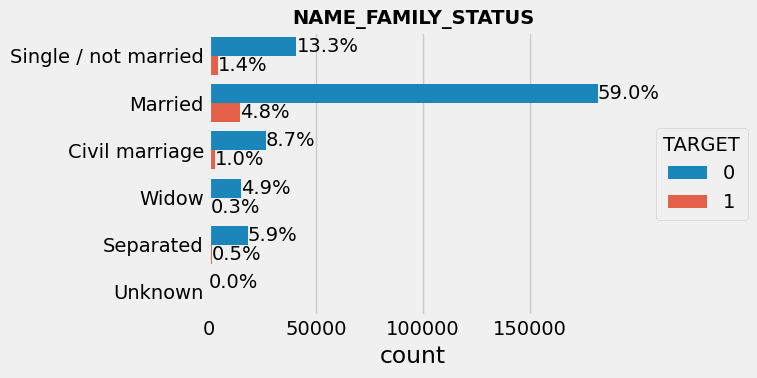

In [27]:
for col in ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']:
    cleaner_helper.plot_categorical_distribution(
        application, col, hue="TARGET")

* Some familly status are unknown rather stored as nan. **This requires reassignment**

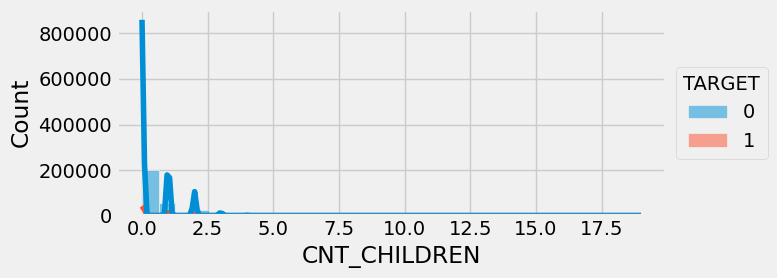

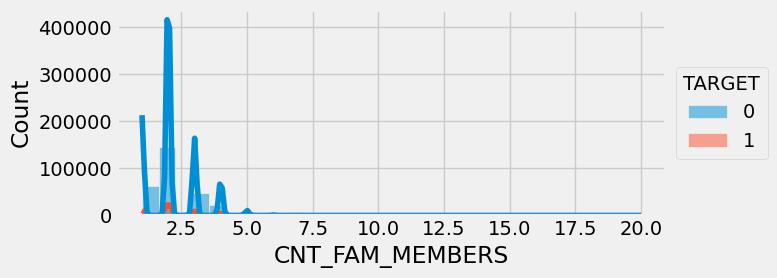

In [28]:
for col in ['CNT_CHILDREN', 'CNT_FAM_MEMBERS']:
    cleaner_helper.plot_numeric_distribution(
        application, col, hue="TARGET")

In [29]:
top_cnt_children = application['CNT_CHILDREN'].value_counts().sort_index().head(20)
display(top_cnt_children)

top_cnt_fam_members = application['CNT_FAM_MEMBERS'].value_counts().sort_index().head(20)
display(top_cnt_fam_members)

CNT_CHILDREN
0     215371
1     61119 
2     26749 
3     3717  
4     429   
5     84    
6     21    
7     7     
8     2     
9     2     
10    2     
11    1     
12    2     
14    3     
19    2     
Name: count, dtype: int64

CNT_FAM_MEMBERS
1.0     67847 
2.0     158357
3.0     52601 
4.0     24697 
5.0     3478  
6.0     408   
7.0     81    
8.0     20    
9.0     6     
10.0    3     
11.0    1     
12.0    2     
13.0    1     
14.0    2     
15.0    1     
16.0    2     
20.0    2     
Name: count, dtype: int64

* Number of children can be approximated as a poisson distribution, thus the values can be considered valid.
* Once again, clipping (or normalisation), will be required for any model that takes magnitudes into account.


<Axes: xlabel='DAYS_BIRTH', ylabel='Count'>

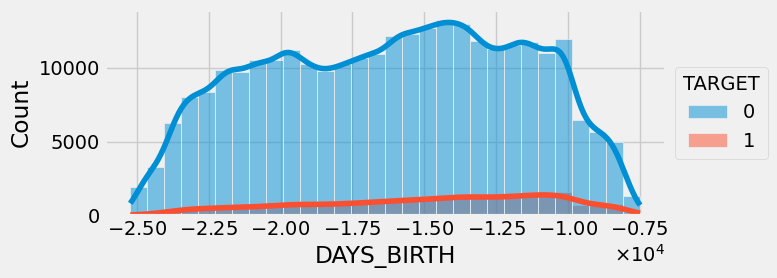

In [30]:
cleaner_helper.plot_numeric_distribution(
    application, 'DAYS_BIRTH', hue="TARGET",)

#### External sources

In [31]:
external_sources = [
    'EXT_SOURCE_1',     
    'EXT_SOURCE_2',    
    'EXT_SOURCE_3'     
]

application_columns['external_sources'] = external_sources

describer.describe(external_sources)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
41,application_train,EXT_SOURCE_1,Normalized score from external data source,normalized,173378,114584,float64,"[0.0830369673913225, 0.3112673113812225, 0.7747614130547695]"
42,application_train,EXT_SOURCE_2,Normalized score from external data source,normalized,660,119831,float64,"[0.2629485927471776, 0.6222457752555098, 0.5559120833904428]"
43,application_train,EXT_SOURCE_3,Normalized score from external data source,normalized,60965,814,float64,"[0.1393757800997895, 0.7295666907060153, 0.6212263380626669]"


* Some external data source was used to give clients a rating.
* These are often missing. Assuming that they are calculated from current features, we could impute the values.
    * Otherwise, the EXT_SOURCE_1 has too many missing values to be meaningful.

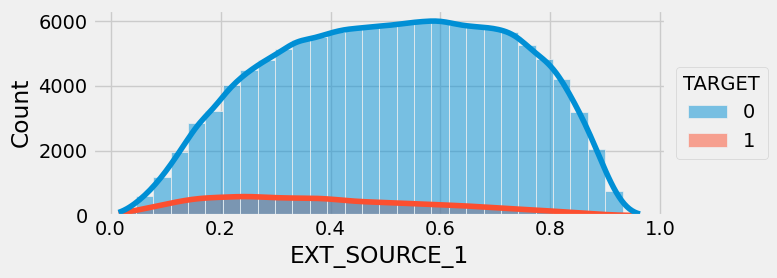

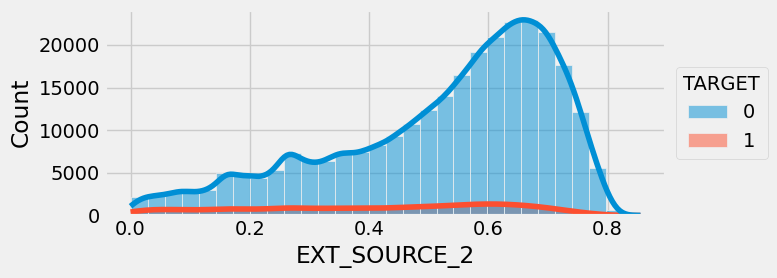

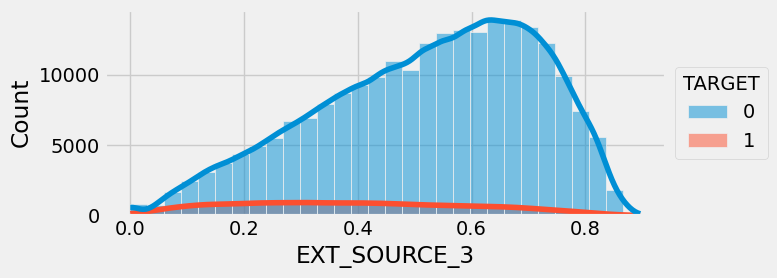

In [32]:
for col in external_sources:
    cleaner_helper.plot_numeric_distribution(
        application, col, hue="TARGET")

The data takes various normal distributions and nicely fits in the range 0 to 1. It is likely that are more powerful technique than normalisation was used on less pretty data.

#### Location features

In [33]:
location_features = [
    'REGION_POPULATION_RELATIVE',  # Region population relative to country
    'REG_REGION_NOT_LIVE_REGION',  # Registration vs living region match
    'REG_REGION_NOT_WORK_REGION',  # Registration vs work region match
    'LIVE_REGION_NOT_WORK_REGION', # Living vs work region match
    'REG_CITY_NOT_LIVE_CITY',      # Registration vs living city match
    'REG_CITY_NOT_WORK_CITY',      # Registration vs work city match
    'LIVE_CITY_NOT_WORK_CITY'      # Living vs work city match
]

application_columns['location_features'] = location_features

describer.describe(location_features)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
16,application_train,REGION_POPULATION_RELATIVE,Normalized population of region where client lives (higher number means the client lives in more populated region),normalized,0,81,float64,"[0.018801, 0.0035409999999999, 0.010032]"
34,application_train,REG_REGION_NOT_LIVE_REGION,"Flag if client's permanent address does not match contact address (1=different, 0=same, at region level)",NaN,0,2,int64,"[0, 1]"
35,application_train,REG_REGION_NOT_WORK_REGION,"Flag if client's permanent address does not match work address (1=different, 0=same, at region level)",NaN,0,2,int64,"[0, 1]"
36,application_train,LIVE_REGION_NOT_WORK_REGION,"Flag if client's contact address does not match work address (1=different, 0=same, at region level)",NaN,0,2,int64,"[0, 1]"
37,application_train,REG_CITY_NOT_LIVE_CITY,"Flag if client's permanent address does not match contact address (1=different, 0=same, at city level)",NaN,0,2,int64,"[0, 1]"
38,application_train,REG_CITY_NOT_WORK_CITY,"Flag if client's permanent address does not match work address (1=different, 0=same, at city level)",NaN,0,2,int64,"[0, 1]"
39,application_train,LIVE_CITY_NOT_WORK_CITY,"Flag if client's contact address does not match work address (1=different, 0=same, at city level)",NaN,0,2,int64,"[0, 1]"


* Full location of each client is known.
* **A lof of location features are if statements based on each other**, thus they will likely yeald better to feature engineering.

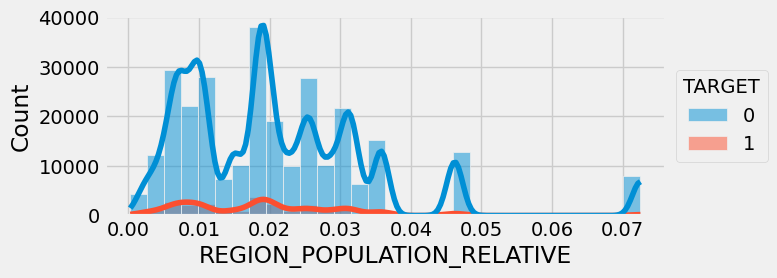

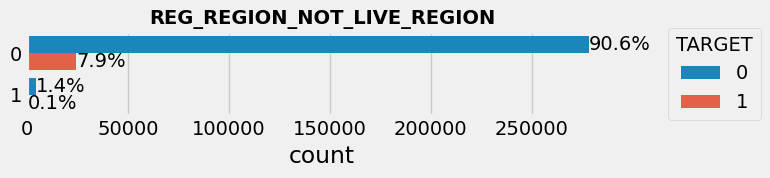

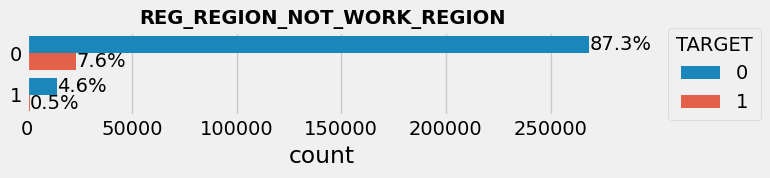

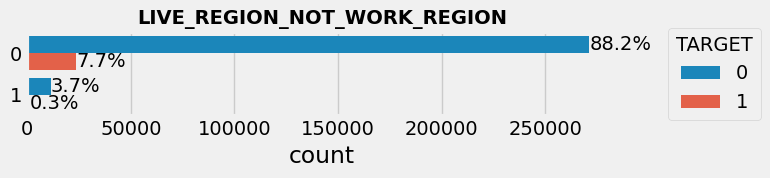

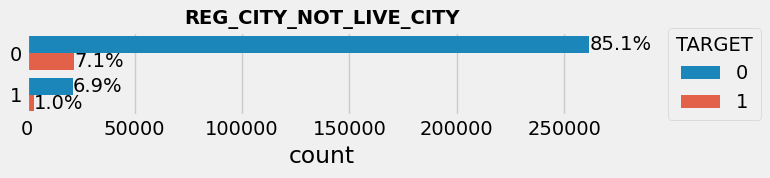

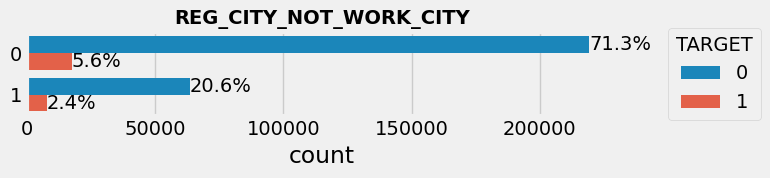

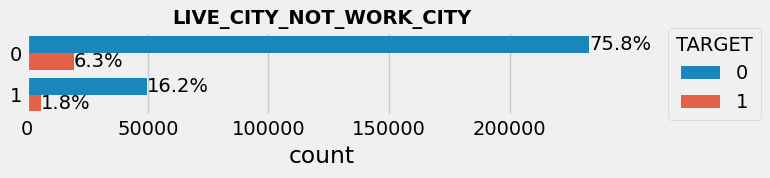

In [34]:
for col in ['REGION_POPULATION_RELATIVE']:
    cleaner_helper.plot_numeric_distribution(
        application, col, hue="TARGET")

for col in ['REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 
           'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
           'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY']:
    cleaner_helper.plot_categorical_distribution(
        application, col, hue="TARGET")

#### Social circle

In [35]:
social_circle = [
    'OBS_30_CNT_SOCIAL_CIRCLE',    # Social circle observations 30 DPD
    'DEF_30_CNT_SOCIAL_CIRCLE',    # Social circle defaults 30 DPD
    'OBS_60_CNT_SOCIAL_CIRCLE',    # Social circle observations 60 DPD
    'DEF_60_CNT_SOCIAL_CIRCLE'     # Social circle defaults 60 DPD
]

application_columns['social_circle'] = social_circle

describer.describe(social_circle)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
91,application_train,OBS_30_CNT_SOCIAL_CIRCLE,How many observation of client's social surroundings with observable 30 DPD (days past due) default,NaN,1021,33,float64,"[2.0, 1.0, 0.0]"
92,application_train,DEF_30_CNT_SOCIAL_CIRCLE,How many observation of client's social surroundings defaulted on 30 DPD (days past due),NaN,1021,10,float64,"[2.0, 0.0, 1.0]"
93,application_train,OBS_60_CNT_SOCIAL_CIRCLE,How many observation of client's social surroundings with observable 60 DPD (days past due) default,NaN,1021,33,float64,"[2.0, 1.0, 0.0]"
94,application_train,DEF_60_CNT_SOCIAL_CIRCLE,How many observation of client's social surroundings defaulted on 60 (days past due) DPD,NaN,1021,9,float64,"[2.0, 0.0, 1.0]"


* Information ofobservation and defaulting on a loan within clients social surrounding are provided.
* Small portion of these values are missing.
    * **A ML sollution (e.g. N-neaserest neighbours) could be used to impute the missing values based on their location and socioeconomic status**

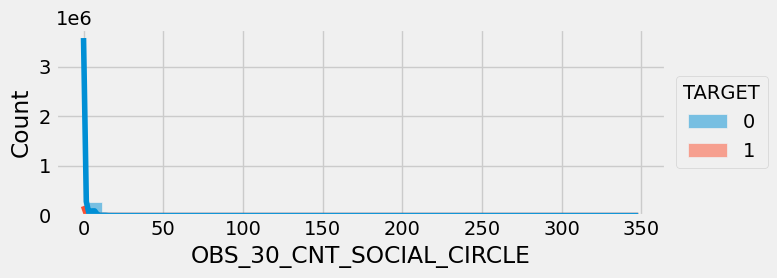

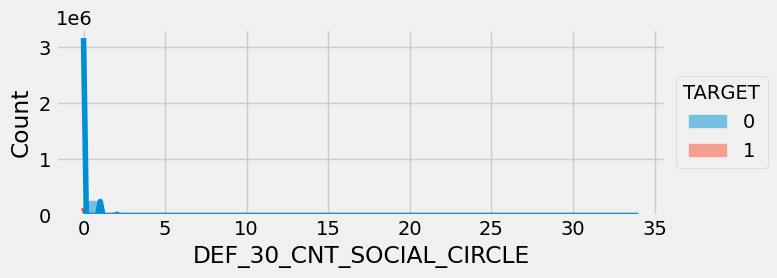

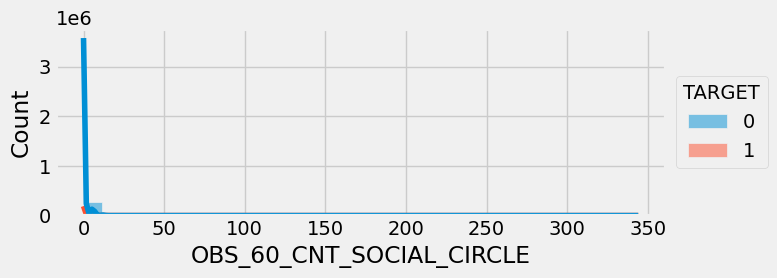

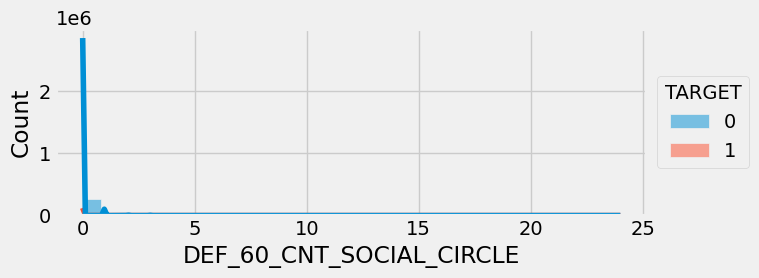

In [36]:
for col in social_circle:
    cleaner_helper.plot_numeric_distribution(
        application, col, hue="TARGET")

#### Document flags

In [37]:
document_flags = [
    'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
    'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
    'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
    'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19',
    'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'
]

application_columns['document_flags'] = document_flags

describer.describe(document_flags)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
96,application_train,FLAG_DOCUMENT_2,Did client provide document 2,NaN,0,2,int64,"[0, 1]"
97,application_train,FLAG_DOCUMENT_3,Did client provide document 3,NaN,0,2,int64,"[1, 0]"
98,application_train,FLAG_DOCUMENT_4,Did client provide document 4,NaN,0,2,int64,"[0, 1]"
99,application_train,FLAG_DOCUMENT_5,Did client provide document 5,NaN,0,2,int64,"[0, 1]"
100,application_train,FLAG_DOCUMENT_6,Did client provide document 6,NaN,0,2,int64,"[0, 1]"
101,application_train,FLAG_DOCUMENT_7,Did client provide document 7,NaN,0,2,int64,"[0, 1]"
102,application_train,FLAG_DOCUMENT_8,Did client provide document 8,NaN,0,2,int64,"[0, 1]"
103,application_train,FLAG_DOCUMENT_9,Did client provide document 9,NaN,0,2,int64,"[0, 1]"
104,application_train,FLAG_DOCUMENT_10,Did client provide document 10,NaN,0,2,int64,"[0, 1]"
105,application_train,FLAG_DOCUMENT_11,Did client provide document 11,NaN,0,2,int64,"[0, 1]"


* There are no missing states in client providing documents for the application.

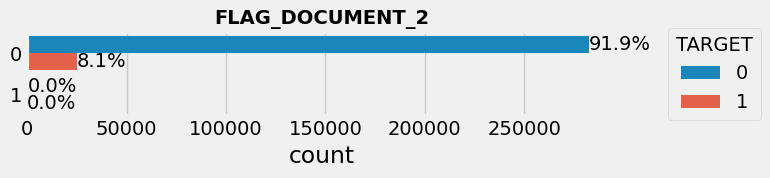

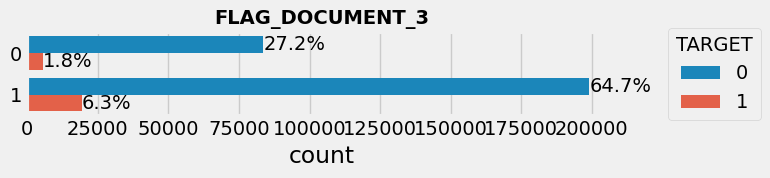

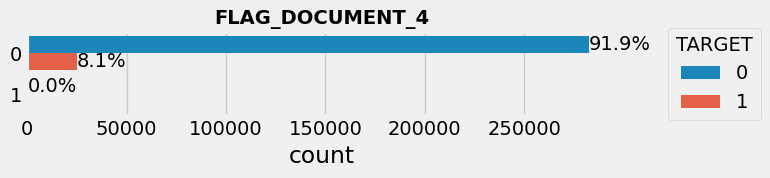

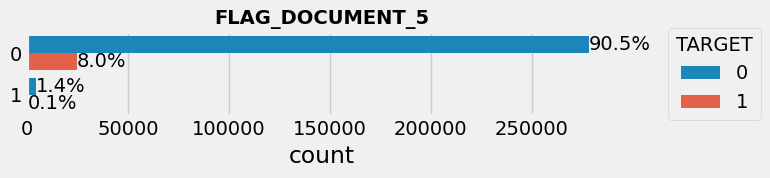

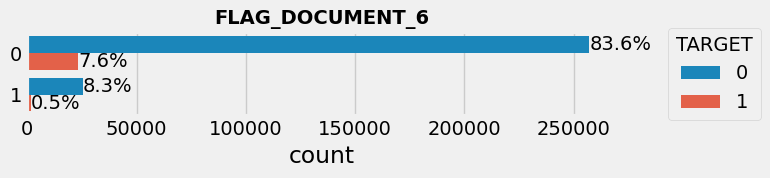

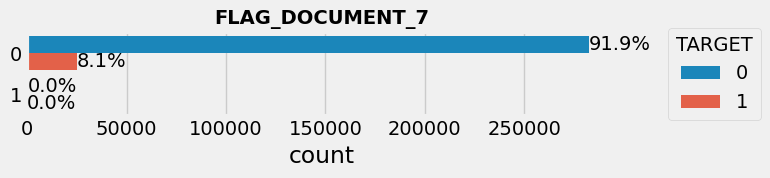

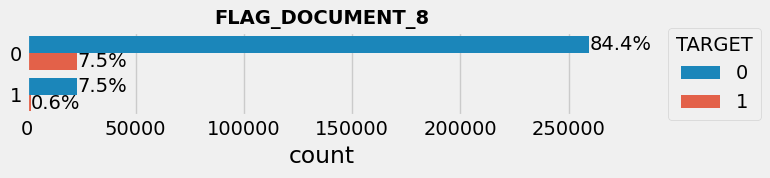

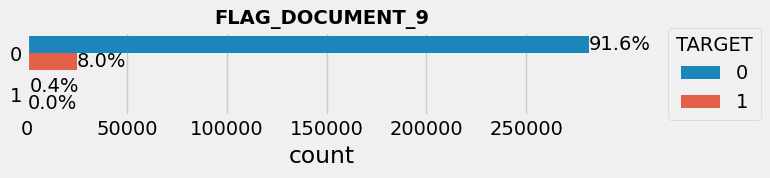

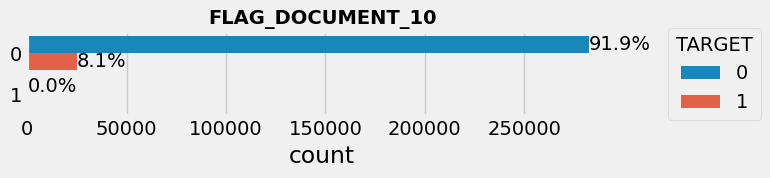

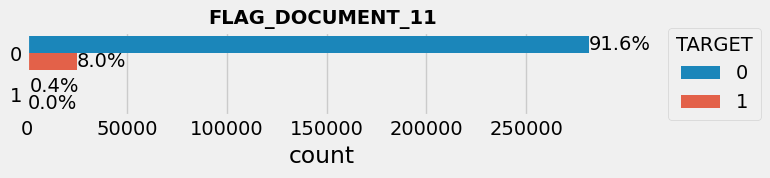

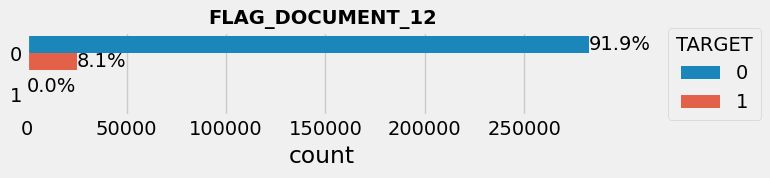

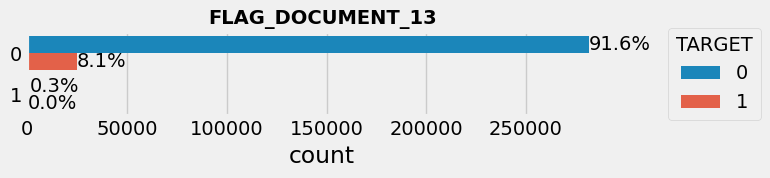

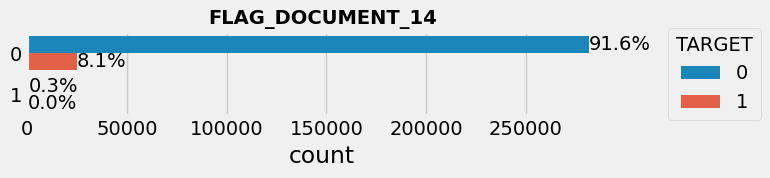

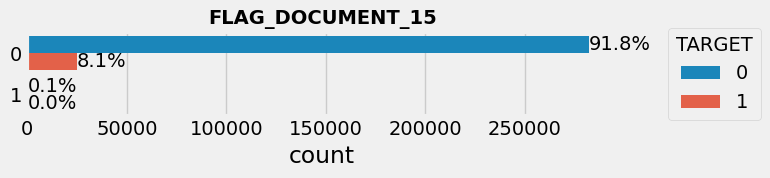

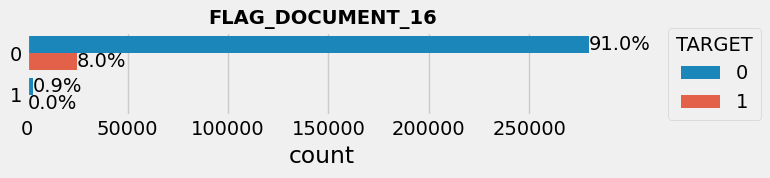

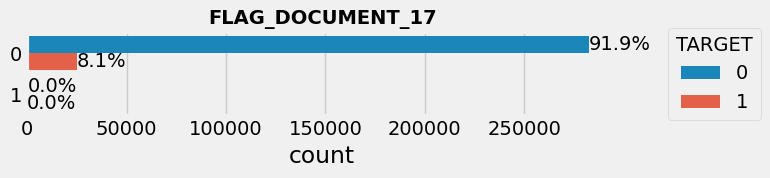

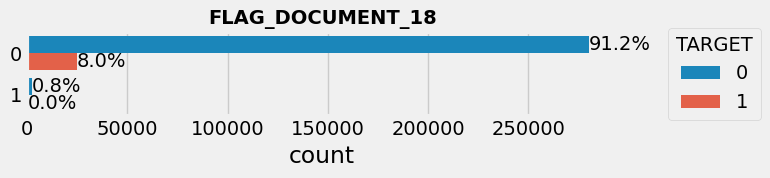

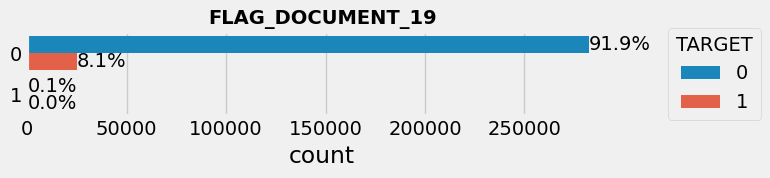

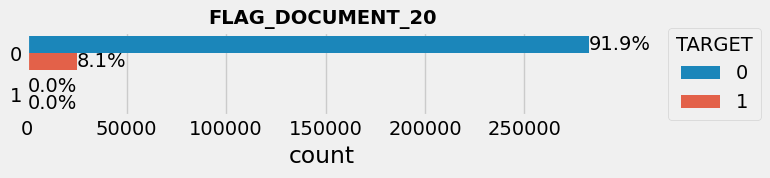

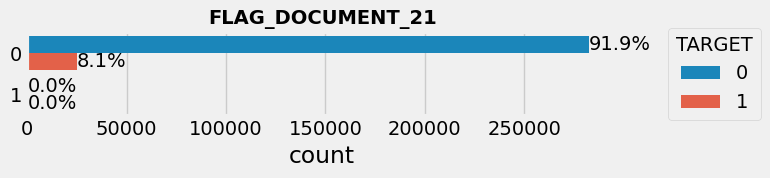

In [38]:
for col in document_flags:
    cleaner_helper.plot_categorical_distribution(
        application, col, hue="TARGET")

* Some documents are always provided. **Applications might not proceed without provision of certain documents**, thus making them either a meaningless feature or a **requirement for application**.

#### Credit bureau enquiries

In [39]:
credit_bureau_enquiries = [
    'AMT_REQ_CREDIT_BUREAU_HOUR',  # Credit bureau requests in hour
    'AMT_REQ_CREDIT_BUREAU_DAY',   # Credit bureau requests in day
    'AMT_REQ_CREDIT_BUREAU_WEEK',  # Credit bureau requests in week
    'AMT_REQ_CREDIT_BUREAU_MON',   # Credit bureau requests in month
    'AMT_REQ_CREDIT_BUREAU_QRT'    # Credit bureau requests in quarter
]

application_columns['credit_bureau_enquiries'] = credit_bureau_enquiries

describer.describe(credit_bureau_enquiries)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
116,application_train,AMT_REQ_CREDIT_BUREAU_HOUR,Number of enquiries to Credit Bureau about the client one hour before application,NaN,41519,5,float64,"[0.0, 1.0, 2.0]"
117,application_train,AMT_REQ_CREDIT_BUREAU_DAY,Number of enquiries to Credit Bureau about the client one day before application (excluding one hour before application),NaN,41519,9,float64,"[0.0, 1.0, 3.0]"
118,application_train,AMT_REQ_CREDIT_BUREAU_WEEK,Number of enquiries to Credit Bureau about the client one week before application (excluding one day before application),NaN,41519,9,float64,"[0.0, 1.0, 3.0]"
119,application_train,AMT_REQ_CREDIT_BUREAU_MON,Number of enquiries to Credit Bureau about the client one month before application (excluding one week before application),NaN,41519,24,float64,"[0.0, 1.0, 2.0]"
120,application_train,AMT_REQ_CREDIT_BUREAU_QRT,Number of enquiries to Credit Bureau about the client 3 month before application (excluding one month before application),NaN,41519,11,float64,"[0.0, 1.0, 2.0]"


* Knowledge on inquiries to credit bureu is absent for a significant portion of clients.

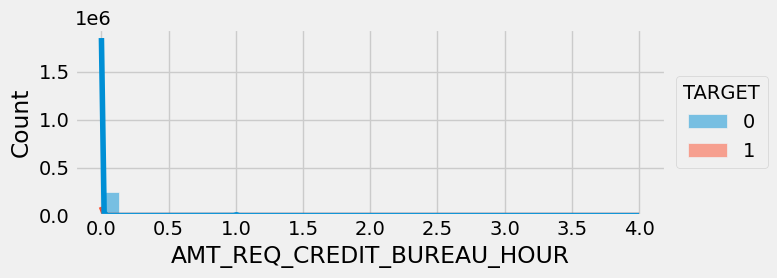

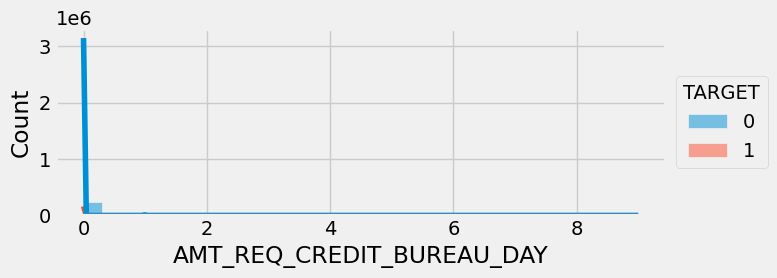

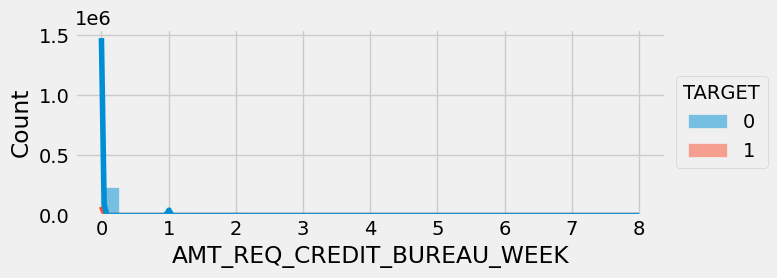

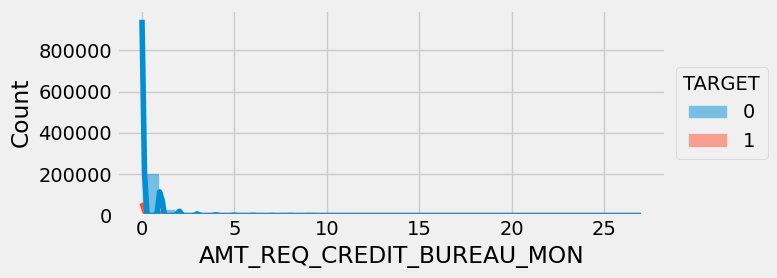

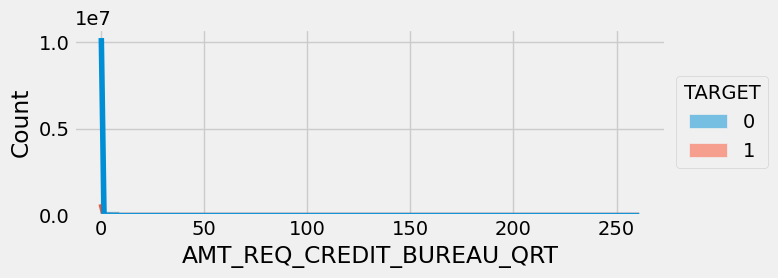

In [40]:
for col in credit_bureau_enquiries:
    cleaner_helper.plot_numeric_distribution(
        application, col, hue="TARGET")

* All distributions are significantly right skewed.

#### Building features

In [41]:
building_avg = [
    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG',
    'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG',
    'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG',
    'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG'
]

application_columns['building_avg'] = building_avg

describer.describe(building_avg)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
44,application_train,APARTMENTS_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,156061,2339,float64,"[0.0247, 0.0959, 0.0825]"
45,application_train,BASEMENTAREA_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,179943,3780,float64,"[0.0369, 0.0529, 0.0973]"
46,application_train,YEARS_BEGINEXPLUATATION_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,150007,285,float64,"[0.9722, 0.9851, 0.9811]"
47,application_train,YEARS_BUILD_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,204488,149,float64,"[0.6192, 0.7959999999999999, 0.7348]"
48,application_train,COMMONAREA_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,214865,3181,float64,"[0.0143, 0.0605, 0.0582]"
49,application_train,ELEVATORS_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,163891,257,float64,"[0.0, 0.08, 0.16]"
50,application_train,ENTRANCES_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,154828,285,float64,"[0.069, 0.0345, 0.2069]"
51,application_train,FLOORSMAX_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,153020,403,float64,"[0.0833, 0.2917, 0.1667]"
52,application_train,FLOORSMIN_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,208642,305,float64,"[0.125, 0.3333, 0.375]"
53,application_train,LANDAREA_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,182590,3527,float64,"[0.0369, 0.013, 0.0135]"


* Most information about patients living conditions are missing. Moreover, these are abstract normalized features.
    * This is a classification task onto itself, consequently, **unsupervised learning algorithm should be used aggregate this data**.

In [42]:
building_mode = [
    'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE',
    'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE',
    'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE',
    'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
]

application_columns['building_mode'] = building_mode

describer.describe(building_mode)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
58,application_train,APARTMENTS_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,156061,760,float64,"[0.0252, 0.0924, 0.084]"
59,application_train,BASEMENTAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,179943,3841,float64,"[0.0383, 0.0538, 0.101]"
60,application_train,YEARS_BEGINEXPLUATATION_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,150007,221,float64,"[0.9722, 0.9851, 0.9811]"
61,application_train,YEARS_BUILD_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,204488,154,float64,"[0.6341, 0.804, 0.7452]"
62,application_train,COMMONAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,214865,3128,float64,"[0.0144, 0.0497, 0.0587]"
63,application_train,ELEVATORS_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,163891,26,float64,"[0.0, 0.0806, 0.1611]"
64,application_train,ENTRANCES_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,154828,30,float64,"[0.069, 0.0345, 0.2069]"
65,application_train,FLOORSMAX_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,153020,25,float64,"[0.0833, 0.2917, 0.1667]"
66,application_train,FLOORSMIN_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,208642,25,float64,"[0.125, 0.3333, 0.375]"
67,application_train,LANDAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,182590,3563,float64,"[0.0377, 0.0128, 0.0138]"


In [43]:
building_medi = [
    'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI',
    'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI',
    'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI',
    'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI'
]

application_columns['building_medi'] = building_medi

describer.describe(building_medi)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
72,application_train,APARTMENTS_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,156061,1148,float64,"[0.025, 0.0968, 0.0833]"
73,application_train,BASEMENTAREA_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,179943,3772,float64,"[0.0369, 0.0529, 0.0973]"
74,application_train,YEARS_BEGINEXPLUATATION_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,150007,245,float64,"[0.9722, 0.9851, 0.9811]"
75,application_train,YEARS_BUILD_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,204488,151,float64,"[0.6243, 0.7987, 0.7383]"
76,application_train,COMMONAREA_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,214865,3202,float64,"[0.0144, 0.0608, 0.0585]"
77,application_train,ELEVATORS_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,163891,46,float64,"[0.0, 0.08, 0.16]"
78,application_train,ENTRANCES_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,154828,46,float64,"[0.069, 0.0345, 0.2069]"
79,application_train,FLOORSMAX_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,153020,49,float64,"[0.0833, 0.2917, 0.1667]"
80,application_train,FLOORSMIN_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,208642,47,float64,"[0.125, 0.3333, 0.375]"
81,application_train,LANDAREA_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,182590,3560,float64,"[0.0375, 0.0132, 0.0137]"


* Identical to previous category, the number of missing values makes sense for unsupervised learning, but not using it as an unique feature.

#### Application process

In [44]:
application_process = [
    'NAME_TYPE_SUITE',         # Who accompanied client
    'NAME_HOUSING_TYPE',       # Housing situation
    'REGION_RATING_CLIENT',    # Region rating
    'REGION_RATING_CLIENT_W_CITY',  # Region rating with city
    'WEEKDAY_APPR_PROCESS_START',   # Application weekday
    'ORGANIZATION_TYPE'        # Organization type
]

application_columns['application_process'] = application_process

describer.describe(application_process)

,Table,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
11,application_train,NAME_TYPE_SUITE,Who was accompanying client when he was applying for the loan,NaN,1292,7,object,"[Unaccompanied, Family, Spouse, partner]"
15,application_train,NAME_HOUSING_TYPE,"What is the housing situation of the client (renting, living with parents, ...)",NaN,0,6,object,"[House / apartment, Rented apartment, With parents]"
30,application_train,REGION_RATING_CLIENT,"Our rating of the region where client lives (1,2,3)",NaN,0,3,int64,"[2, 1, 3]"
31,application_train,REGION_RATING_CLIENT_W_CITY,"Our rating of the region where client lives with taking city into account (1,2,3)",NaN,0,3,int64,"[2, 1, 3]"
32,application_train,WEEKDAY_APPR_PROCESS_START,On which day of the week did the client apply for the loan,NaN,0,7,object,"[WEDNESDAY, MONDAY, THURSDAY]"
40,application_train,ORGANIZATION_TYPE,Type of organization where client works,NaN,0,58,object,"[Business Entity Type 3, School, Government]"


* Client coming in alone or with others was not always marked.
* All other variables are present.
* A lot of these can be used as proxies for quality of life, however **region rating is rather questionable and should be investigated for VIF**.

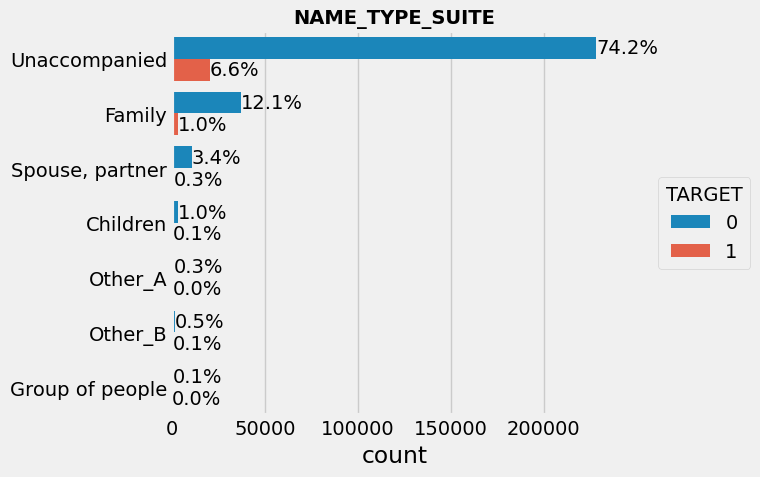

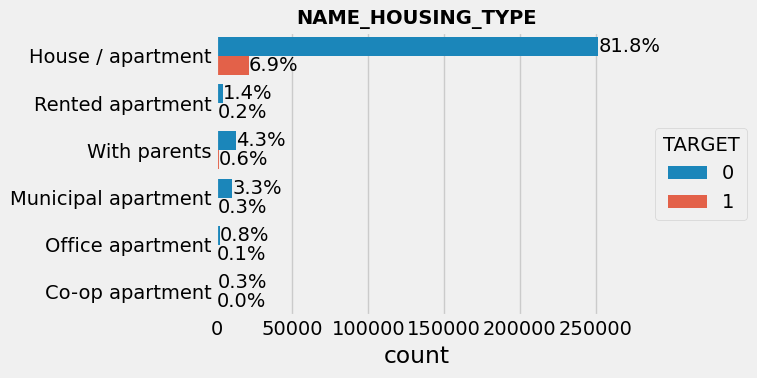

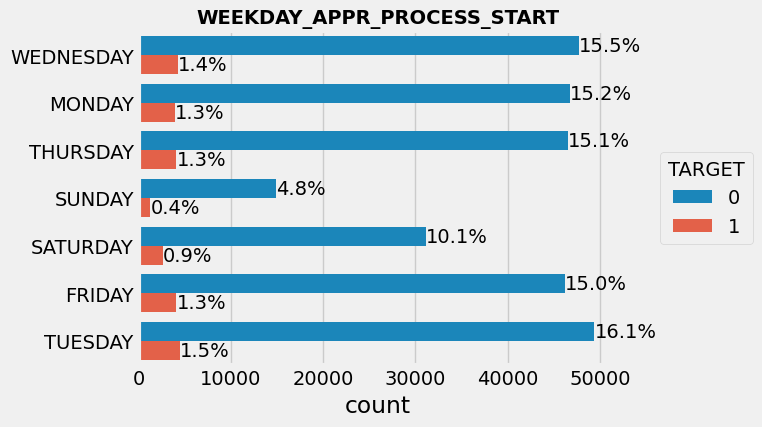

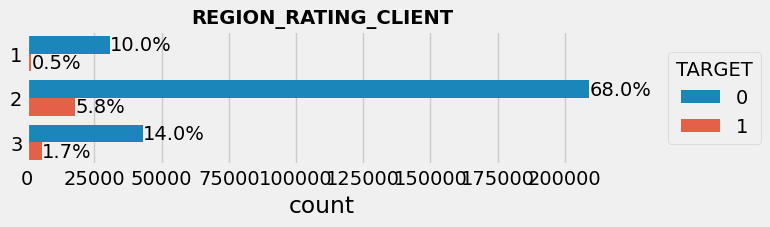

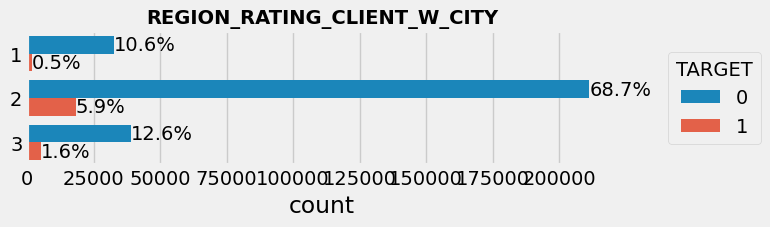

In [45]:
for col in ['NAME_TYPE_SUITE', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']:
    cleaner_helper.plot_categorical_distribution(
        application, col, hue="TARGET")


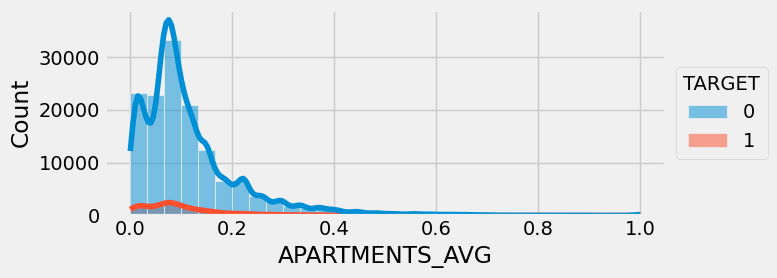

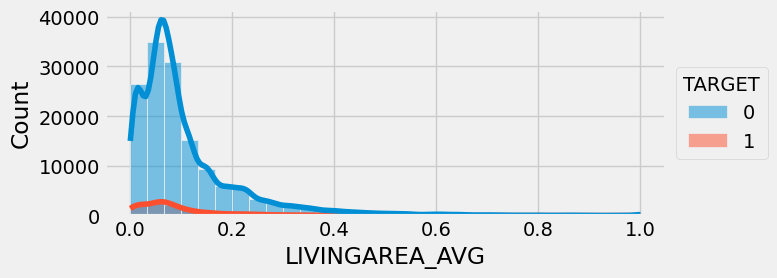

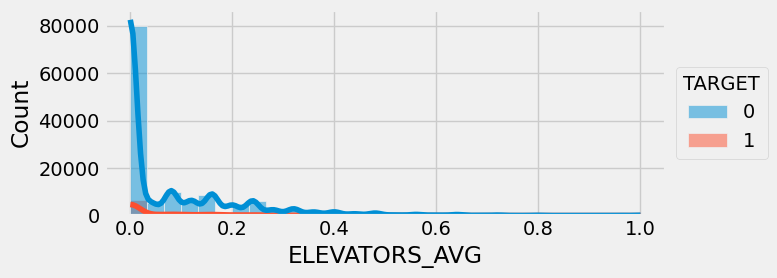

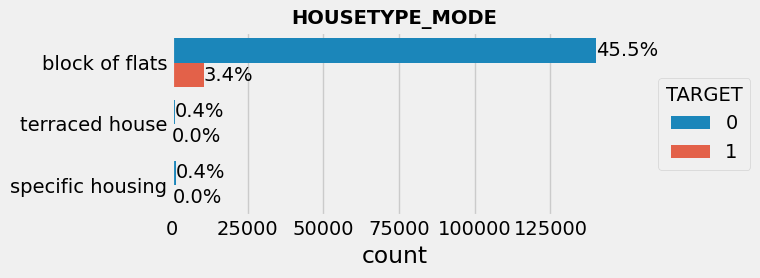

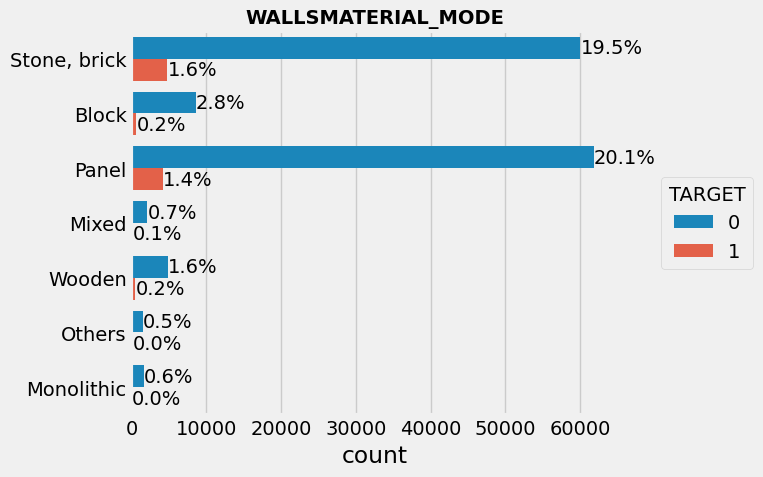

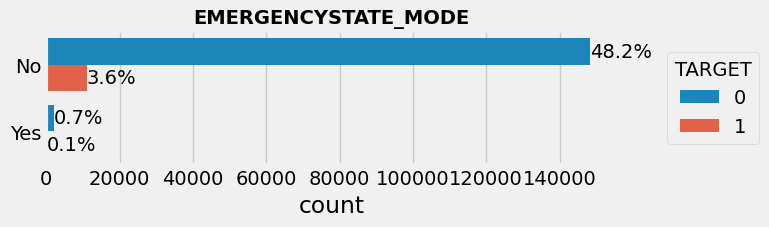

In [46]:
# Building features visualization - plotting sample of features
sample_building_avg = ['APARTMENTS_AVG', 'LIVINGAREA_AVG', 'ELEVATORS_AVG']
for col in sample_building_avg:
    cleaner_helper.plot_numeric_distribution(
        application, col, hue="TARGET")

sample_building_mode = ['HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
for col in sample_building_mode:
    cleaner_helper.plot_categorical_distribution(
        application, col, hue="TARGET")

## Column check

In [66]:
# Flatten all unique column names from application_columns dictionary
flattened_columns = []
for cols in application_columns.values():
    flattened_columns.extend(cols)
flattened_columns = set(flattened_columns)

print(f"Number of unique application columns in application_columns: {len(flattened_columns)}")
print("Missing columns:", set(descriptions[descriptions.Table =='application_data.csv'].Row).difference(flattened_columns))



Number of unique application columns in application_columns: 120
Missing columns: set()


All the columns were succesfully investigated.

### Application Actionables: